<a href="https://colab.research.google.com/github/YuriArduino/Estudos_Artificial_Intelligence/blob/Proto_Projects/Analise_de_sentimentos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Análise de Sentimentos com LLM e Visualização Avançada

##Visão Geral

>Este notebook implementa um sistema completo de análise de sentimentos utilizando Large Language Models (LLM) com estruturação de dados via Pydantic e visualizações interativas. O projeto analisa reviews de produtos/serviços, classificando sentimentos, intensidade e extraindo aspectos mencionados.
Características Principais

##Análise Estruturada: Uso de Pydantic para garantir consistência dos dados de saída

*  LLM Integration: Integração com Google Gemini via LangChain
*  Análise Multidimensional: Extração de sentimento, intensidade e aspectos
*  Visualizações Avançadas: Gráficos interativos com Plotly e dashboards com Matplotlib
*  Controle de Rate Limiting: Gestão automática de limites de API
*  Logging Estruturado: Sistema de logs com fuso horário brasileiro

# Estrutura do Projeto

##1.1   Configuração Inicial

###1.1  Instalação e importação de dependências

In [21]:
!pip install -q pandas matplotlib seaborn langchain_community langchain_google_genai faiss-cpu pymupdf requests

### 1.2  Setup do ambiente de logging com timezone de Brasília (UTC-3)

In [22]:
import logging
from datetime import datetime
import pytz  # biblioteca já disponível no Colab

# Define o fuso horário de Brasília (UTC-3)
brasilia_tz = pytz.timezone("America/Sao_Paulo")

class TZFormatter(logging.Formatter):
    def formatTime(self, record, datefmt=None):
        dt = datetime.fromtimestamp(record.created, tz=brasilia_tz)
        return dt.strftime(datefmt or "%H:%M:%S")

# Configuração global de logs
handler = logging.StreamHandler()
handler.setFormatter(TZFormatter("%(asctime)s | %(levelname)-7s | %(message)s"))

logging.basicConfig(
    level=logging.INFO,
    handlers=[handler],
    force=True
)

logger = logging.getLogger(__name__)
logger.info("Logging configurado com Sucesso - Horário de Brasília (UTC-3).")


15:52:37 | INFO    | Logging configurado com Sucesso - Horário de Brasília (UTC-3).


##2 Carregamento de Dados

###2.1 Classe DocumentLoader: Download e persistência de arquivos

In [23]:
import logging
import time
from pathlib import Path
from typing import List
from urllib.parse import unquote

import requests

logger = logging.getLogger(__name__)


class DocumentLoader:
    """
    Carrega documentos de URLs e grava-os em uma pasta persistente (por padrão /content/tmp).
    Ajusta os metadados 'source' usando o nome original do arquivo.
    """

    def __init__(self, timeout: int = 20, persist_dir: str = "/content/tmp"):
        self.timeout = timeout
        self.persist_dir = Path(persist_dir)
        self.persist_dir.mkdir(parents=True, exist_ok=True)

    @staticmethod
    def _extrair_nome_arquivo(url: str) -> str:
        """Extrai o nome do arquivo de uma URL, decodificando caracteres especiais."""
        return unquote(url.split("/")[-1]) or f"download_{int(time.time())}.dat"

    def _gerar_caminho_unico(self, nome_arquivo: str) -> Path:
        """Gera um caminho único dentro de self.persist_dir sem sobrescrever existente."""
        destino = self.persist_dir / nome_arquivo
        if not destino.exists():
            return destino
        # se já existe, adiciona timestamp antes da extensão
        stem = destino.stem
        suffix = destino.suffix or ""
        novo_nome = f"{stem}_{int(time.time())}{suffix}"
        return self.persist_dir / novo_nome

    def _baixar(self, url: str) -> Path:
        """
        Baixa um arquivo de uma URL e salva em self.persist_dir.
        Retorna o caminho do arquivo gravado.
        """
        dl_url = (
            url + "?raw=true"
            if "github.com" in url and "?raw=true" not in url
            else url
        )

        logger.debug(f"Iniciando download de: {dl_url}")
        response = requests.get(dl_url, timeout=self.timeout)
        response.raise_for_status()

        nome_arquivo = self._extrair_nome_arquivo(url)
        caminho_final = self._gerar_caminho_unico(nome_arquivo)

        # grava bytes no caminho final
        caminho_final.write_bytes(response.content)
        logger.debug(f"Arquivo gravado em: {caminho_final}")

        return caminho_final

    def carregar(self, urls: List[str]) -> List[Path]:
        """
        Baixa e armazena os arquivos (persistentes) em self.persist_dir.
        Retorna a lista de caminhos dos arquivos criados.
        """
        logger.info("Iniciando o carregamento de documentos...")
        arquivos: List[Path] = []

        for url in urls:
            nome = self._extrair_nome_arquivo(url)
            try:
                caminho = self._baixar(url)
                arquivos.append(caminho)
                logger.info(f"✅ '{nome}' carregado com sucesso em: {caminho}")
            except Exception as e:
                logger.error(f"❌ Erro ao carregar '{nome}': {e}")

        logger.info("Processo concluído.")
        return arquivos

urls = [
    "https://raw.githubusercontent.com/YuriArduino/Estudos_Artificial_Intelligence/refs/heads/Dados/TestReviews.csv"
]

loader = DocumentLoader(timeout=20, persist_dir="/content/tmp")
arquivos_baixados = loader.carregar(urls)

logger.info("Arquivos baixados:")
for arquivo in arquivos_baixados:
    logger.info(f"  - {arquivo}")

15:52:42 | INFO    | Iniciando o carregamento de documentos...
15:52:43 | INFO    | ✅ 'TestReviews.csv' carregado com sucesso em: /content/tmp/TestReviews_1758221563.csv
15:52:43 | INFO    | Processo concluído.
15:52:43 | INFO    | Arquivos baixados:
15:52:43 | INFO    |   - /content/tmp/TestReviews_1758221563.csv


###2.2 Carregamento do dataset de reviews

In [24]:
import logging
from pathlib import Path
import pandas as pd
from IPython.display import display

logger = logging.getLogger(__name__)

# Verifica se a variável existe no ambiente
if 'arquivos_baixados' in locals() and arquivos_baixados:
    csv_file_path = arquivos_baixados[0]  # pode ser Path ou str
    csv_path = Path(csv_file_path)

    try:
        if not csv_path.exists():
            logger.error(f"❌ O arquivo {csv_path} não foi encontrado no sistema de arquivos.")
            # Dica: verifique o valor de csv_path; por exemplo:
            logger.debug(f"Caminho verificado: {csv_path.resolve()}")
        else:
            df_loaded_csv = pd.read_csv(csv_path)
            df_reviews = df_loaded_csv.copy()
            logger.info(f"✅ CSV carregado com sucesso: {csv_path}")
            display(df_reviews.head())

    except FileNotFoundError:
        logger.error(f"❌ O arquivo {csv_path} não foi encontrado.")
    except Exception as e:
        logger.error(f"❌ Um erro ocorreu ao carregar o CSV: {e}")
else:
    logger.error("❌ Nenhum arquivo foi baixado na etapa anterior ou a variável 'arquivos_baixados' não está disponível.")


15:52:47 | INFO    | ✅ CSV carregado com sucesso: /content/tmp/TestReviews_1758221563.csv


,review,class
0,Fantastic spot for an even or a quite cocktail...,1
1,"Love, love, love the calamari. It's so good an...",1
2,"Love this place. Stiff martinis and cocktails,...",1
3,It's everything a great cocktail bar should be...,1
4,"I came here before a pirates game, so it was a...",1


In [25]:
df_reviews["class"].value_counts()

,count
class,
1,2989
0,1332


In [64]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4321 entries, 0 to 4320
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  4321 non-null   object
 1   class   4321 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 67.6+ KB


###2.3Amostragem aleatória para teste (40 reviews)

In [28]:
# Extrai a coluna de reviews
coluna_de_reviews = df_reviews["review"]

# Escolhe 40 reviews aleatórias e as salva em uma nova variável
test_reviews = coluna_de_reviews.sample(n=40, random_state=42) # Usando o random_state = 42 para reprodutibilidade


print("Os 5 primeiros reviews aleatórios escolhidos para o test:")
display(test_reviews.head())

print(f"\nTotal de reviews para test_reviews: {len(test_reviews)}")

Os 5 primeiros reviews aleatórios escolhidos para o test:


,review
1073,Awesome! It is sooo much fun for me to take p...
856,The Rhythm Room was the first blues bar I visi...
1222,"As a former BR employee, I'm very hard on my s..."
3406,"Sadly, the professionalism of the front desk n..."
2250,4.5 .5 off for hard ass tires.This is awesome ...



Total de reviews para test_reviews: 40


##3 Configuração do LLM

###3.1 Classe LlmmodelLoader: Configuração do Google Gemini

In [68]:
import os
import logging
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI

logger = logging.getLogger(__name__)

class LlmmodelLoader:
    """
    Carrega e configura um modelo LLM usando a API do Google Gemini.
    """

    def carregar_modelos(self, model: str = "gemini-2.5-flash", temperature: float = 0):
        try:
            logger.info("--- Carregando modelos ---")

            # Obtém e valida a chave da API
            api_key = userdata.get("GEMINI_API_KEY")
            if not api_key:
                raise RuntimeError("Chave GEMINI_API_KEY não encontrada no userdata do Colab.")
            os.environ["GOOGLE_API_KEY"] = api_key

            # Inicializa o modelo
            llm = ChatGoogleGenerativeAI(model=model, temperature=temperature)

            logger.info(f"✅ Modelo '{model}' configurado com sucesso!")
            return llm

        except Exception as e:
            logger.error(f"❌ Erro na configuração do modelo: {e}")
            return None


if __name__ == "__main__":
    loader = LlmmodelLoader()
    llm_model = loader.carregar_modelos()

    if llm_model:
        logger.info("Modelo LLM carregado com sucesso.")
    else:
        logger.error("Falha ao carregar o modelo LLM.")


17:19:22 | INFO    | --- Carregando modelos ---
17:19:22 | INFO    | ✅ Modelo 'gemini-2.5-flash' configurado com sucesso!
17:19:22 | INFO    | Modelo LLM carregado com sucesso.


##4 Modelo de Dados Estruturado

*  Classe LlmmodelLoader: Configuração do Google Gemini
*  Integração via LangChain com controle de temperatura

###4.1 Integração Pydantic + LangChain com fallback robusto

In [30]:


import logging
from typing import List, Dict, Any, Optional
import time

from pydantic import BaseModel, Field, ValidationError, model_validator
from langchain.output_parsers import PydanticOutputParser
from langchain.schema import SystemMessage, HumanMessage
# Nota: dependendo da sua versão do LangChain, as importações acima podem variar.
# Se alguma importação falhar, me diga que eu adapto.

logger = logging.getLogger(__name__)

# ------------------ Modelo Pydantic de saída ------------------

class TriagemOut(BaseModel):
    sentiment: str = Field(..., description="Positiva, Negativa ou Neutra")
    intensity: str = Field(..., description="Alta, Média ou Baixa")
    aspects: List[str] = Field(default_factory=list, description="Lista de aspectos mencionados")
    explanation: str = Field("", description="Explicação curta em português")

    @model_validator(mode='before')
    def normalizar_campos(cls, values: Dict[str, Any]) -> Dict[str, Any]:
        # Normaliza nomes alternativos e formatos simples
        # aceita keys em português/inglês
        if "sentimento" in values and "sentiment" not in values:
            values["sentiment"] = values.pop("sentimento")
        if "intensidade" in values and "intensity" not in values:
            values["intensity"] = values.pop("intensidade")
        if "aspectos" in values and "aspects" not in values:
            values["aspects"] = values.pop("aspectos")
        # força tipos básicos
        if "aspects" in values and isinstance(values["aspects"], str):
            # transforma "a,b" em lista
            values["aspects"] = [a.strip() for a in values["aspects"].split(",") if a.strip()]
        return values

    @model_validator(mode='after')
    def validar_valores(self) -> 'TriagemOut':
        # Normaliza strings e valida opções esperadas
        s = self.sentiment.strip().capitalize()
        if s not in {"Positiva", "Negativa", "Neutra"}:
            # tenta mapear algumas variantes
            map_ = {"Positive":"Positiva","Negative":"Negativa","Neutral":"Neutra"}
            s = map_.get(s, "Neutra")
        self.sentiment = s

        i = self.intensity.strip().capitalize()
        i = i.replace("Media", "Média")  # corrige sem acento
        if i not in {"Alta", "Média", "Baixa"}:
            i = "Média" if self.sentiment != "Neutra" else "Baixa"
        self.intensity = i

        # garante lista de strings
        asp = self.aspects or []
        if not isinstance(asp, list):
            asp = list(asp)
        self.aspects = [str(a).strip() for a in asp if str(a).strip()]

        # explicação curta
        self.explanation = self.explanation.strip()

        return self

logger.info("✅ Modelo Pydantic 'TriagemOut' carregado com sucesso.")

###4.2 Prompt de sistema (template)

In [31]:
TRIAGEM_PROMPT = """
Você é um assistente que deve analisar uma resenha de produto/serviço e RESPONDER APENAS com um OBJETO JSON válido que obedeça ao esquema:
- sentiment: "Positiva" | "Negativa" | "Neutra"
- intensity: "Alta" | "Média" | "Baixa"
- aspects: lista de palavras curtas (ex.: ["qualidade","entrega"])
- explanation: 1-2 frases explicando a decisão

Responda SOMENTE o JSON, sem texto adicional.
"""

logger.info("✅ Prompt de triagem carregado com sucesso.")

###4.3 Chain estruturada

In [32]:
triagem_chain = None
parser: Optional[PydanticOutputParser] = None

try:
    if hasattr(llm_model, "with_structured_output"):
        # cria a chain estruturada (API mais direta)
        triagem_chain = llm_model.with_structured_output(TriagemOut)
        logger.info("✅Usando 'with_structured_output' do LLM para saída Pydantic.")
    else:
        # fallback: usa PydanticOutputParser e fará parsing manual do texto retornado
        parser = PydanticOutputParser(pydantic_schema=TriagemOut)
        logger.info("with_structured_output não disponível; usando PydanticOutputParser como fallback.")
except Exception as e:
    # Fallback em caso de alguma execeção durante try block
    parser = PydanticOutputParser(pydantic_schema=TriagemOut)
    logger.warning(f"Falha ao tentar criar chain estruturada: {e}. Usando parser como fallback.")

16:08:09 | INFO    | Usando 'with_structured_output' do LLM para saída Pydantic.


In [ ]:
###4.4 Função triagem que usa chain ou parser

In [33]:
def triagem(mensagem: str, max_retries: int = 2, backoff_base: int = 2) -> Dict[str, Any]:
    """
    Invoca a chain/LLM para triagem e retorna um dict validado pelo Pydantic.
    Em caso de erros repetidos, lança Exception para quem chamar tratar.
    """
    tentativa = 0
    last_exc = None

    while tentativa <= max_retries:
        try:
            # Se temos triagem_chain (with_structured_output), usamos o método invoke com mensagens
            if triagem_chain is not None:
                saida_pydantic: TriagemOut = triagem_chain.invoke([
                    SystemMessage(content=TRIAGEM_PROMPT),
                    HumanMessage(content=mensagem)
                ])
                return saida_pydantic.model_dump()

            # Fallback: chamamos o LLM com prompt simples e usamos parser para validar
            # Concatena sistema + conteúdo
            prompt_text = TRIAGEM_PROMPT + "\n\nResenha: " + mensagem
            # algumas integrações aceitam .invoke(prompt) ou callable(llm_model)
            if hasattr(llm_model, "invoke"):
                resposta = llm_model.invoke(prompt_text)
                # extrai texto bruto de forma segura
                raw_text = getattr(resposta, "content", None) or getattr(resposta, "text", None) or str(resposta)
            else:
                # outros LLMs no LangChain são "callable"
                resposta = llm_model(prompt_text)
                raw_text = getattr(resposta, "content", None) or getattr(resposta, "text", None) or str(resposta)

            raw_text = str(raw_text).strip()
            # Parser tenta extrair JSON e validar com Pydantic
            validated = parser.parse(raw_text)  # retorna instância de TriagemOut
            return validated.model_dump()

        except ValidationError as ve:
            # Se a validação falhar, talvez o modelo retornou texto fora do padrão.
            # Dependendo do caso, podemos tentar limpar e revalidar ou rejeitar.
            logger.warning(f"Validação Pydantic falhou na tentativa {tentativa+1}: {ve}")
            last_exc = ve
            # tentar novamente após backoff
        except Exception as e:
            logger.error(f"Erro ao invocar triagem na tentativa {tentativa+1}: {e}")
            last_exc = e

        tentativa += 1
        if tentativa <= max_retries:
            backoff = backoff_base ** (tentativa - 1)
            logger.info(f"Aguardando {backoff}s antes da próxima tentativa ({tentativa}/{max_retries})...")
            time.sleep(backoff)

    # se saiu do loop sem sucesso
    raise RuntimeError(f"Falha ao executar triagem após {max_retries+1} tentativas. Erro: {last_exc}")

###4.5 Integrar ao GoogleDrive

In [36]:
from google.colab import drive
import logging

logger = logging.getLogger(__name__)

drive.mount('/content/drive')
logger.info("✅ Google Drive montado com sucesso.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##5 Pipeline de Análise

*   Processamento com fallback e retry automático
*   Validação de dados com Pydantic
*   Sistema de pausas para controle de rate limiting

###5.1 Processamento e Integração com DataFrame

In [37]:
# Parâmetros de controle

PAUSA_A_CADA = 10  # Pausa a cada N chamadas
PAUSA_SEGUNDOS = 14 # Duração da pausa
MAX_RETRIES_CALL = 2 # Tentativas por chamada
BACKOFF_BASE = 2 # Base para o backoff exponencial entre tentativas

# listas para armazenar resultados enriquecidos
lista_sentimentos = []
lista_intensidades = []
lista_aspects = []
lista_explicacoes = []

total = len(test_reviews)
calls = 0

logger.info(f"Iniciando triagem estruturada para {total} resenhas...")

for idx, texto in enumerate(test_reviews, start=1):
    try:
        # chama a função triagem que retorna dict validado
        resultado = triagem(texto, max_retries=MAX_RETRIES_CALL, backoff_base=BACKOFF_BASE)
        calls += 1

        # extrai campos com segurança
        lista_sentimentos.append(resultado.get("sentiment", "Neutra"))
        lista_intensidades.append(resultado.get("intensity", "Média"))
        lista_aspects.append(resultado.get("aspects", []))
        lista_explicacoes.append(resultado.get("explanation", ""))

    except Exception as e:
        logger.error(f"Falha ao processar resenha {idx}/{total}: {e}")
        # fallback: valores neutros
        lista_sentimentos.append("Neutra")
        lista_intensidades.append("Baixa")
        lista_aspects.append([])
        lista_explicacoes.append("")

    # pausa periódica para não ultrapassar o limite da API:
    if calls % PAUSA_A_CADA == 0:
        logger.info(f"Pausa de {PAUSA_SEGUNDOS}s para evitar limites...")
        time.sleep(PAUSA_SEGUNDOS)

    # log de progresso
    if idx % 10 == 0 or idx == total:
        logger.info(f"Progresso: {idx}/{total} resenhas processadas.")

logger.info("✅Triagem estruturada concluída.")

# monta DataFrame final com colunas enriquecidas
import pandas as pd
from IPython.display import display

df_result = pd.DataFrame({
    "Review": test_reviews,
    "Sentiment": pd.Series(lista_sentimentos, index=test_reviews.index),
    "Intensity": pd.Series(lista_intensidades, index=test_reviews.index),
    "Aspects": pd.Series(lista_aspects, index=test_reviews.index),
    "Explanation": pd.Series(lista_explicacoes, index=test_reviews.index),
})

logger.info("Exibindo resultados (primeiras linhas):")
display(df_result.head())

# (Opcional) salva no Drive: descomente e ajuste o caminho se quiser persistência
df_result.to_csv("/content/drive/MyDrive/analises_sentimentos_enriquecidas.csv", index=False)

16:19:26 | INFO    | Iniciando triagem estruturada para 40 resenhas...
16:20:09 | INFO    | Pausa de 14s para evitar limites...
16:20:23 | INFO    | Progresso: 10/40 resenhas processadas.
16:21:08 | INFO    | Pausa de 14s para evitar limites...
16:21:22 | INFO    | Progresso: 20/40 resenhas processadas.
16:22:00 | INFO    | Pausa de 14s para evitar limites...
16:22:14 | INFO    | Progresso: 30/40 resenhas processadas.
16:22:50 | INFO    | Pausa de 14s para evitar limites...
16:23:04 | INFO    | Progresso: 40/40 resenhas processadas.
16:23:04 | INFO    | Triagem estruturada concluída.
16:23:04 | INFO    | Exibindo resultados (primeiras linhas):


,Review,Sentiment,Intensity,Aspects,Explanation
1073,Awesome! It is sooo much fun for me to take p...,Positiva,Alta,"[artista, pintura, velocidade, atendimento, qu...",A cliente teve uma experiência extremamente po...
856,The Rhythm Room was the first blues bar I visi...,Positiva,Alta,"[Música, Shows, Atendimento, Preço, Ambiente]","A resenha é extremamente positiva, elogiando a..."
1222,"As a former BR employee, I'm very hard on my s...",Positiva,Alta,"[atendimento, equipe, experiência de compra]",A cliente teve uma experiência de compra muito...
3406,"Sadly, the professionalism of the front desk n...",Negativa,Alta,"[atendimento, espera, profissionalismo, corte]",A resenha é altamente negativa devido à falta ...
2250,4.5 .5 off for hard ass tires.This is awesome ...,Positiva,Alta,"[velocidade, pista, pneus, preço, experiência ...",O usuário expressa grande entusiasmo pela expe...


In [43]:
import pandas as pd

file_path = "/content/drive/MyDrive/analises_sentimentos_enriquecidas.csv"

try:
    df_analises = pd.read_csv(file_path)
    print(f"✅ Arquivo '{file_path}' lido com sucesso!")
    display(df_analises)

except FileNotFoundError:
    print(f"❌ O arquivo '{file_path}' não foi encontrado. Certifique-se de que o Google Drive está montado e o caminho está correto.")
except Exception as e:
    print(f"❌ Ocorreu um erro ao ler o arquivo: {e}")

✅ Arquivo '/content/drive/MyDrive/analises_sentimentos_enriquecidas.csv' lido com sucesso!


,Review,Sentiment,Intensity,Aspects,Explanation
0,Awesome! It is sooo much fun for me to take p...,Positiva,Alta,"['artista', 'pintura', 'velocidade', 'atendime...",A cliente teve uma experiência extremamente po...
1,The Rhythm Room was the first blues bar I visi...,Positiva,Alta,"['Música', 'Shows', 'Atendimento', 'Preço', 'A...","A resenha é extremamente positiva, elogiando a..."
2,"As a former BR employee, I'm very hard on my s...",Positiva,Alta,"['atendimento', 'equipe', 'experiência de comp...",A cliente teve uma experiência de compra muito...
3,"Sadly, the professionalism of the front desk n...",Negativa,Alta,"['atendimento', 'espera', 'profissionalismo', ...",A resenha é altamente negativa devido à falta ...
4,4.5 .5 off for hard ass tires.This is awesome ...,Positiva,Alta,"['velocidade', 'pista', 'pneus', 'preço', 'exp...",O usuário expressa grande entusiasmo pela expe...
5,"Just to clarify, my rating for this business i...",Negativa,Alta,"['serviço', 'comunicação', 'prazo de entrega']",O cliente expressa forte insatisfação com o se...
6,I've been waiting to change from four stars to...,Positiva,Alta,"['atendimento', 'comida', 'bebida', 'ambiente'...",O cliente teve uma excelente experiência gastr...
7,In the last 6 months Ricks has definitely had ...,Positiva,Alta,"['equipe do bar', 'coquetéis', 'petiscos', 'DJ...",A resenha descreve uma experiência fantástica ...
8,"Oh my, I love Sir Ed's. It is without a doubt ...",Positiva,Alta,"['bar', 'qualidade', 'comida', 'ambiente', 'se...","A resenha expressa um amor profundo pelo bar, ..."
9,This is my favorite place to visit for some de...,Positiva,Alta,"['frutas', 'sanduíches', 'atendimento', 'negóc...","A resenha é extremamente positiva, elogiando a..."


##6 Visualizações

*  Gráfico Pizza: Distribuição de sentimentos
*  Barra Empilhada: Sentimento por intensidade
*  Top Aspectos: Aspectos mais mencionados
*  Heatmap: Correlação aspectos x sentimentos
*  Dashboard Consolidado: PNG de alta resolução

In [44]:
import ast
from collections import Counter
import pandas as pd

df = df_result.copy()

# converte 'Aspects' que podem estar como string para listas
def parse_aspects(x):
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        # fallback: tenta limpeza simples
        if not x or pd.isna(x):
            return []
        return [s.strip() for s in str(x).strip("[]").split(",") if s.strip()]

df["Aspects_parsed"] = df["Aspects"].apply(parse_aspects)


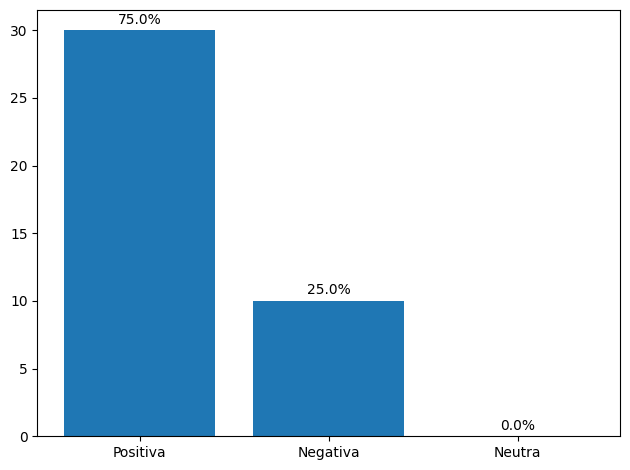

In [67]:
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd

counts = df['Sentiment'].value_counts().reindex(['Positiva','Negativa','Neutra'], fill_value=0)
percent = (counts / counts.sum() * 100).round(1)

# Gráfico de Pizza (Donut)
fig1 = px.pie(names=counts.index, values=counts.values, title='Distribuição de Sentimentos', hole=0.4)
fig1.update_traces(textinfo='percent+label')
fig1.show()

# Gráfico de tabelas
fig, ax = plt.subplots()
bars = ax.bar(counts.index, counts.values)
# MOstra a porcentagem no topo das barras
for rect, p in zip(bars, percent.values):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height()+0.5, f"{p}%", ha="center")

plt.tight_layout()
plt.show()

In [53]:
import plotly.express as px

# suposição: df_result já existe e tem colunas: 'Review','Sentiment','Intensity','Aspects','Explanation'
df = df_result.copy()

fig = px.bar(df, x='Sentiment', color='Intensity', barmode='stack', category_orders={'Sentiment':['Positiva','Negativa','Neutra'], 'Intensity':['Alta','Média','Baixa']})
fig.update_layout(title="Sentimento por Intensidade")
fig.show()

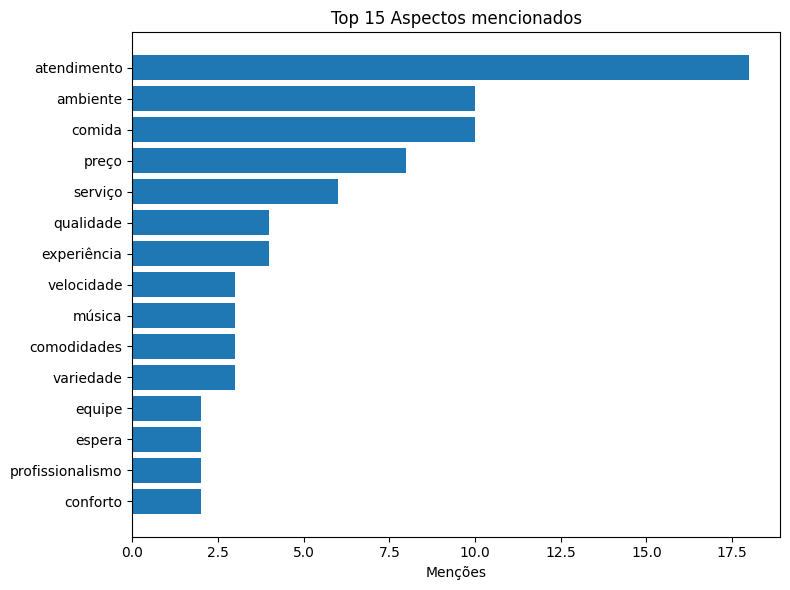

In [55]:
import ast
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt


# suposição: df_result já existe e tem colunas: 'Review','Sentiment','Intensity','Aspects','Explanation'
df = df_result.copy()

# convert 'Aspects' that may be strings to lists
def parse_aspects(x):
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        # fallback: simple cleaning
        if not x or pd.isna(x):
            return []
        return [s.strip() for s in str(x).strip("[]").split(",") if s.strip()]

df["Aspects_parsed"] = df["Aspects"].apply(parse_aspects)


all_aspects = Counter()
df['Aspects_parsed'].apply(lambda lst: all_aspects.update([a.lower() for a in lst if a]))

top_n = 15
most_common = all_aspects.most_common(top_n)
aspects, counts = zip(*most_common)

fig, ax = plt.subplots(figsize=(8,6))
ax.barh(aspects[::-1], counts[::-1])  # inverte para ordenar do maior ao menor top->bottom
ax.set_title(f"Top {top_n} Aspectos mencionados")
ax.set_xlabel("Menções")
plt.tight_layout()
plt.show()

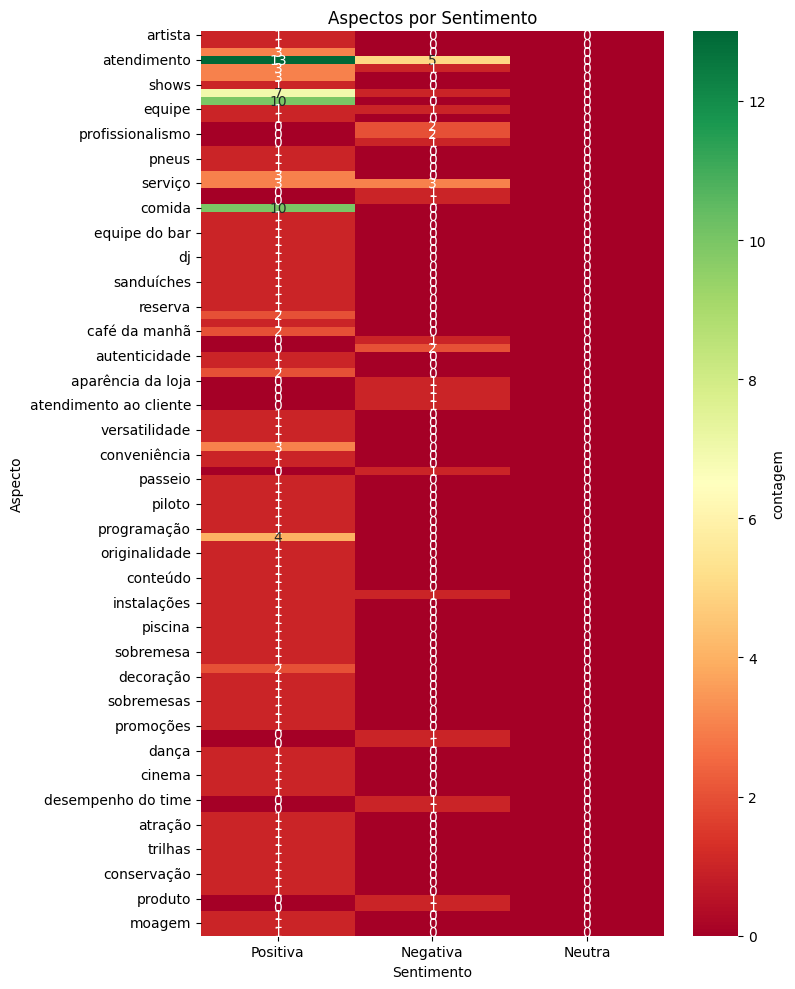

In [57]:
from collections import defaultdict
mat = defaultdict(lambda: Counter())

for _, row in df.iterrows():
    s = row['Sentiment']
    for a in row['Aspects_parsed']:
        mat[a.lower()][s] += 1

# transforma em DataFrame
mat_df = pd.DataFrame(mat).T.fillna(0).reindex(columns=['Positiva','Negativa','Neutra'], fill_value=0)
import seaborn as sns  # se quiser heatmap; seaborn é opcional
plt.figure(figsize=(8,10))
sns.heatmap(mat_df, annot=True, fmt='g', cmap='RdYlGn', cbar_kws={'label':'contagem'})
plt.title("Aspectos por Sentimento")
plt.xlabel("Sentimento")
plt.ylabel("Aspecto")
plt.tight_layout()
plt.show()


In [56]:
# resenhas mais "intensas" positivas/negativas
exemplos = []
for s in ['Positiva','Negativa','Neutra']:
    subset = df[df['Sentiment']==s]
    # prioriza intensidade Alta, depois aleatório
    subset_high = subset[subset['Intensity']=='Alta']
    if not subset_high.empty:
        exemplos.append(subset_high.sample(1).iloc[0])
    elif not subset.empty:
        exemplos.append(subset.sample(1).iloc[0])

# exibe
pd.DataFrame(exemplos)[['Review','Sentiment','Intensity','Aspects','Explanation']]

,Review,Sentiment,Intensity,Aspects,Explanation
1552,Considering the fact that San Diego cannot sup...,Positiva,Alta,"[ambiente, música, dança, diversidade]",A cliente ficou muito impressionada com o ambi...
3559,"Just to clarify, my rating for this business i...",Negativa,Alta,"[serviço, comunicação, prazo de entrega]",O cliente expressa forte insatisfação com o se...


In [58]:
import plotly.express as px
fig = px.sunburst(df, path=['Sentiment','Intensity'], title='Sentimento e Intensidade (Sunburst)')
fig.show()


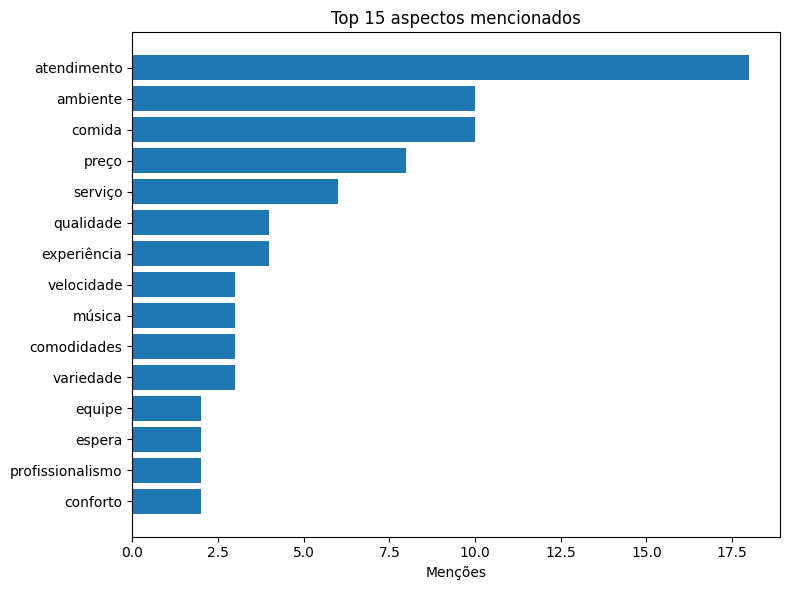

,Review,Sentiment,Intensity,Aspects,Explanation
0,Great Diner! Their breakfast is the best in t...,Positiva,Alta,"[café da manhã, variedade, ambiente, comida, p...",O restaurante oferece um excelente café da man...
1,Horrible service. Barely acknowledged when you...,Negativa,Alta,"[serviço, atendimento, espera, pagamento]",O cliente teve uma experiência muito ruim com ...


16:36:39 | INFO    | Resumo final:
16:36:39 | INFO    |   Positiva: 30 (75.0%)
16:36:39 | INFO    |   Negativa: 10 (25.0%)
16:36:39 | INFO    |   Neutra: 0 (0.0%)


In [59]:
# Célula: visualizações dos resultados de sentimento (Colab)
import logging
import ast
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
from IPython.display import display, HTML

logger = logging.getLogger(__name__)

# ---------- checagem inicial ----------
if 'df_result' not in globals():
    raise RuntimeError("A variável `df_result` não foi encontrada. Execute a célula que gera o DataFrame antes desta.")

df = df_result.copy()

# ---------- função segura para parsear 'Aspects' ----------
def parse_aspects(x):
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        if pd.isna(x) or not x:
            return []
        # fallback simples: split por vírgula dentro de colchetes ou texto
        s = str(x).strip()
        s = s.strip("[]")
        return [part.strip().strip("'\"") for part in s.split(",") if part.strip()]

df['Aspects_parsed'] = df['Aspects'].apply(parse_aspects)

# ---------- 1) Donut / Pizza: distribuição de Sentiment ----------
order_sent = ['Positiva', 'Negativa', 'Neutra']
counts = df['Sentiment'].value_counts().reindex(order_sent, fill_value=0)
percent = (counts / counts.sum() * 100).round(1)

fig1 = px.pie(
    names=counts.index,
    values=counts.values,
    title="Distribuição de Sentimentos",
    hole=0.4
)
fig1.update_traces(textinfo='percent+label', hovertemplate='%{label}: %{value} resenhas (%{percent})')
fig1.show()

# ---------- 2) Barra empilhada: Sentiment × Intensity ----------
# Garante colunas de intensidade consistentes
df['Intensity'] = df['Intensity'].fillna('Média').replace({'Media':'Média'})
int_order = ['Alta','Média','Baixa']

pivot = df.pivot_table(index='Sentiment', columns='Intensity', aggfunc='size', fill_value=0).reindex(order_sent).fillna(0)
# garante colunas na ordem
for c in int_order:
    if c not in pivot.columns:
        pivot[c] = 0
pivot = pivot[int_order]

fig2 = px.bar(
    pivot.reset_index(),
    x='Sentiment',
    y=int_order,
    title='Sentimento por Intensidade (empilhado)',
    labels={'value':'Número de resenhas','Sentiment':'Sentimento'},
    category_orders={'Sentiment': order_sent, 'Intensity': int_order}
)
fig2.update_layout(barmode='stack')
fig2.show()

# ---------- 3) Top N aspectos mencionados (barra horizontal, Matplotlib) ----------
all_aspects = Counter()
df['Aspects_parsed'].apply(lambda lst: all_aspects.update([a.lower() for a in lst if a and isinstance(a, str)]))
top_n = 15
most_common = all_aspects.most_common(top_n)

if most_common:
    aspects, counts_as = zip(*most_common)
    fig3, ax3 = plt.subplots(figsize=(8, max(4, len(aspects)*0.4)))
    ax3.barh(aspects[::-1], counts_as[::-1])
    ax3.set_title(f"Top {len(aspects)} aspectos mencionados")
    ax3.set_xlabel("Menções")
    plt.tight_layout()
    plt.show()
else:
    logger.info("Nenhum aspecto detectado para plotagem.")

# ---------- 4) Tabela de exemplos representativos (1 por sentimento) ----------
exemplos = []
for s in order_sent:
    subset = df[df['Sentiment'] == s]
    # prioriza intensidade 'Alta' e, em seguida, 'Média'
    subset_high = subset[subset['Intensity'].str.lower() == 'alta']
    if not subset_high.empty:
        exemplos.append(subset_high.sample(1).iloc[0])
    else:
        subset_med = subset[subset['Intensity'].str.lower() == 'média']
        if not subset_med.empty:
            exemplos.append(subset_med.sample(1).iloc[0])
        elif not subset.empty:
            exemplos.append(subset.sample(1).iloc[0])
# converte para DataFrame cuidando do caso vazio
if exemplos:
    df_exemplos = pd.DataFrame(exemplos)[['Review','Sentiment','Intensity','Aspects','Explanation']]
    display(HTML("<h3>Exemplos representativos por Sentimento</h3>"))
    display(df_exemplos.reset_index(drop=True))
else:
    logger.info("Não há exemplos para exibir.")

# ---------- 5) Heatmap aspecto × sentimento (opcional, Plotly) ----------
# cria matriz aspecto x sentimento (contagem)
from collections import defaultdict
mat = defaultdict(lambda: Counter())
for _, row in df.iterrows():
    s = row['Sentiment']
    for a in row['Aspects_parsed']:
        if a and isinstance(a, str):
            mat[a.lower()][s] += 1

if mat:
    mat_df = pd.DataFrame(mat).T.fillna(0).reindex(columns=order_sent, fill_value=0)
    # mantém apenas top_k aspectos para legibilidade
    top_k_aspects = 25
    mat_df = mat_df.loc[mat_df.sum(axis=1).sort_values(ascending=False).index[:top_k_aspects]]
    fig4 = px.imshow(
        mat_df,
        labels=dict(x="Sentimento", y="Aspecto", color="Contagem"),
        x=mat_df.columns,
        y=mat_df.index,
        aspect="auto",
        title="Aspectos por Sentimento (top {})".format(len(mat_df))
    )
    fig4.update_xaxes(side="top")
    fig4.show()
else:
    logger.info("Matriz de aspectos vazia; heatmap não gerado.")

# ---------- resumo numérico final ----------
summary_counts = counts.to_dict()
summary_percent = percent.to_dict()
logger.info("Resumo final:")
for k in order_sent:
    logger.info(f"  {k}: {summary_counts.get(k,0)} ({summary_percent.get(k,0)}%)")

# ---------- (opcional) salvar figuras e resultados ----------
# plt.savefig('/content/plot_aspects.png', dpi=150, bbox_inches='tight')
# df.to_csv('/content/drive/MyDrive/analises_sentimentos_visualizacao.csv', index=False)


16:43:09 | INFO    | Dashboard salvo como PNG em: /content/drive/MyDrive/analises_sentimentos_dashboard.png


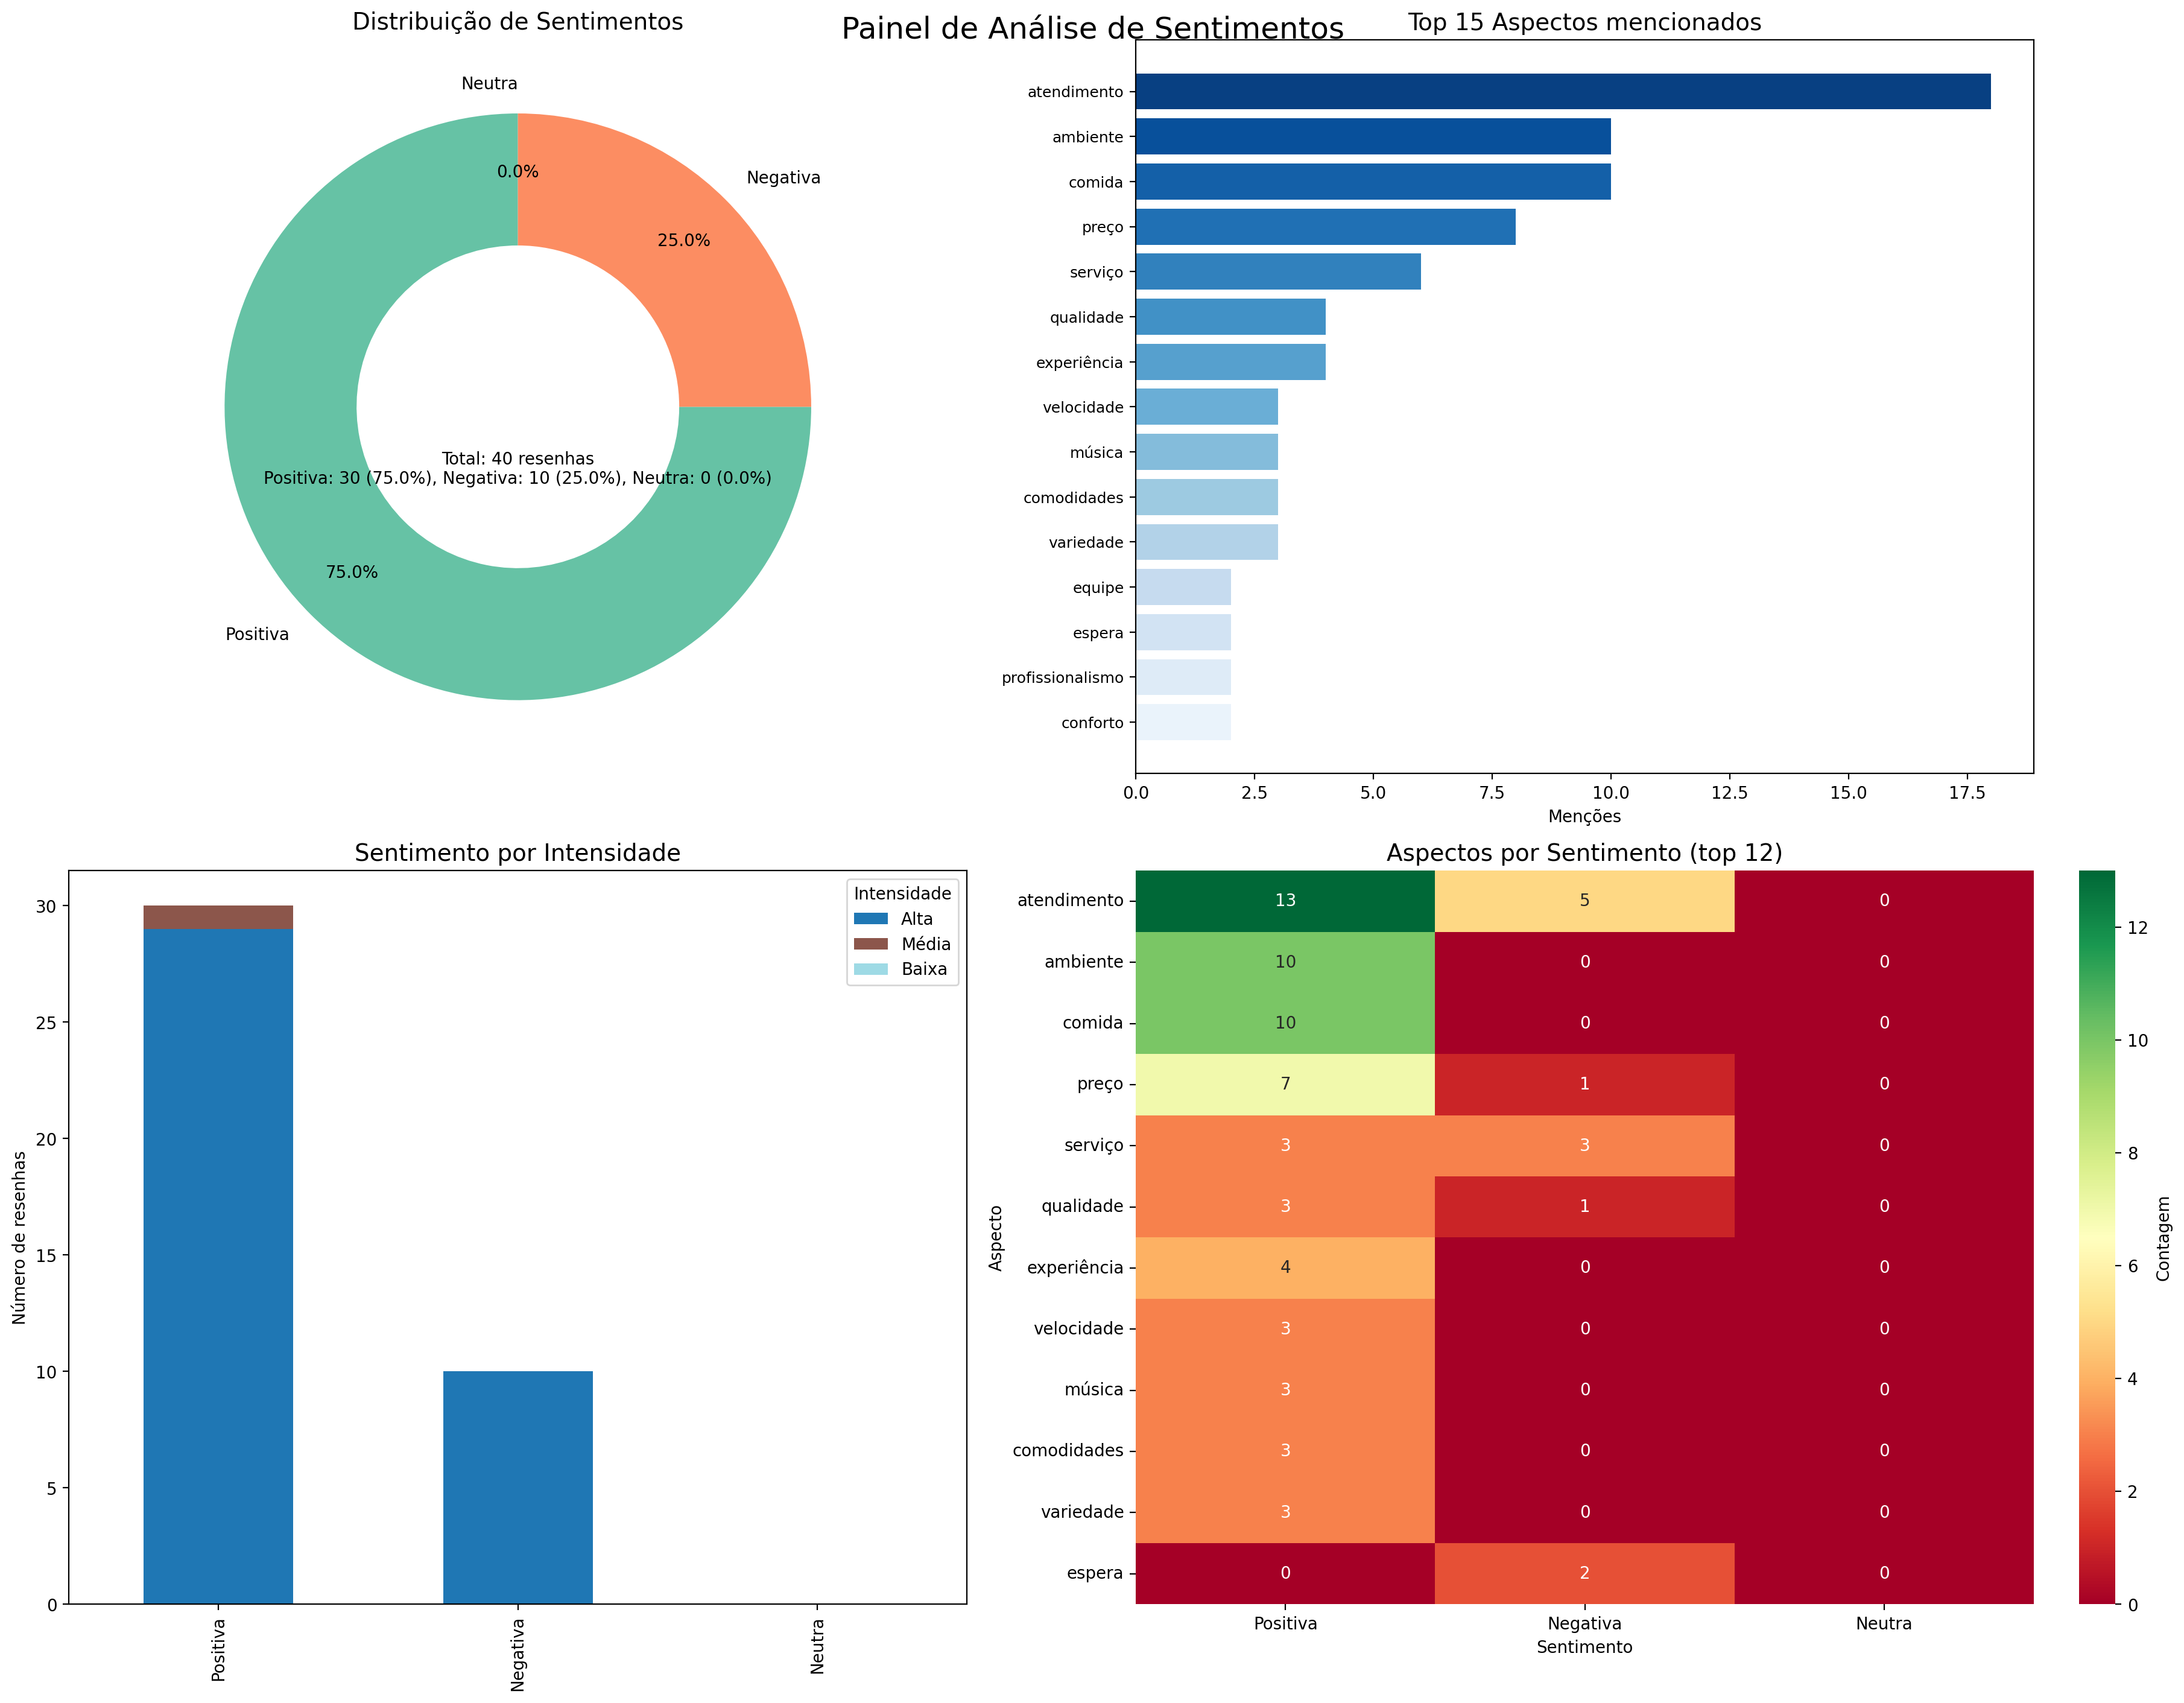

In [62]:
# Gera um PNG único com vários gráficos organizados (Colab)
import ast
import logging
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from PIL import Image
from IPython.display import display, HTML

logger = logging.getLogger(__name__)

# ---------- Verificação inicial ----------
if 'df_result' not in globals():
    raise RuntimeError("A variável `df_result` não foi encontrada. Execute a célula que gera o DataFrame antes desta.")

df = df_result.copy()

# ---------- Função segura para parsear 'Aspects' ----------
def parse_aspects(x):
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        if pd.isna(x) or not x:
            return []
        s = str(x).strip()
        s = s.strip("[]")
        return [part.strip().strip("'\"") for part in s.split(",") if part.strip()]

df['Aspects_parsed'] = df['Aspects'].apply(parse_aspects)

# ---------- Preparação dos dados ----------
order_sent = ['Positiva', 'Negativa', 'Neutra']
df['Sentiment'] = df['Sentiment'].fillna('Neutra')
counts = df['Sentiment'].value_counts().reindex(order_sent, fill_value=0)
percent = (counts / counts.sum() * 100).round(1)

# Intensidade pivot
df['Intensity'] = df['Intensity'].fillna('Média').replace({'Media':'Média'})
pivot = df.pivot_table(index='Sentiment', columns='Intensity', aggfunc='size', fill_value=0).reindex(order_sent).fillna(0)
for col in ['Alta','Média','Baixa']:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[['Alta','Média','Baixa']]

# Top aspectos
all_aspects = Counter()
df['Aspects_parsed'].apply(lambda lst: all_aspects.update([a.lower() for a in lst if a and isinstance(a, str)]))
top_n = 15
most_common = all_aspects.most_common(top_n)

# Heatmap (aspecto x sentimento) para top_k_aspects
top_k_aspects = 12
mat = defaultdict(lambda: Counter())
for _, row in df.iterrows():
    s = row['Sentiment']
    for a in row['Aspects_parsed']:
        if a and isinstance(a, str):
            mat[a.lower()][s] += 1

mat_df = pd.DataFrame(mat).T.fillna(0)
for col in order_sent:
    if col not in mat_df.columns:
        mat_df[col] = 0
mat_df = mat_df[order_sent]
# seleciona top_k por soma total
if not mat_df.empty:
    mat_df = mat_df.loc[mat_df.sum(axis=1).sort_values(ascending=False).index[:top_k_aspects]]

# ---------- Layout da figura (2x2) ----------
fig = plt.figure(constrained_layout=True, figsize=(18, 14))  # grande para alta resolução no PNG
gs = fig.add_gridspec(2, 2)

# Donut (top-left)
ax0 = fig.add_subplot(gs[0, 0])
sizes = counts.values
labels = counts.index
colors = sns.color_palette("Set2", n_colors=len(labels))
wedges, texts, autotexts = ax0.pie(sizes, labels=labels, startangle=90, wedgeprops=dict(width=0.45), colors=colors, autopct='%1.1f%%', pctdistance=0.80)
ax0.set_title("Distribuição de Sentimentos", fontsize=14)
# adicionar contagem central
total = counts.sum()
ax0.text(0, -0.15, f"Total: {total} resenhas\n" + ", ".join([f"{k}: {counts[k]} ({percent[k]}%)" for k in labels]), ha='center', va='top', fontsize=10)

# Barra empilhada (bottom-left)
ax1 = fig.add_subplot(gs[1, 0])
pivot.plot(kind='bar', stacked=True, ax=ax1, colormap='tab20')
ax1.set_title("Sentimento por Intensidade", fontsize=14)
ax1.set_ylabel("Número de resenhas")
ax1.set_xlabel("")
ax1.legend(title="Intensidade", loc='upper right')

# Top aspectos (top-right)
ax2 = fig.add_subplot(gs[0, 1])
if most_common:
    aspects, counts_as = zip(*most_common)
    ax2.barh(aspects[::-1], counts_as[::-1], color=sns.color_palette("Blues", n_colors=len(aspects)))
    ax2.set_title(f"Top {len(aspects)} Aspectos mencionados", fontsize=14)
    ax2.set_xlabel("Menções")
else:
    ax2.text(0.5, 0.5, "Nenhum aspecto detectado", ha='center', va='center')
    ax2.set_title("Top Aspectos", fontsize=14)
ax2.tick_params(axis='y', labelsize=9)

# Heatmap (bottom-right)
ax3 = fig.add_subplot(gs[1, 1])
if not mat_df.empty:
    sns.heatmap(mat_df, annot=True, fmt='g', cmap='RdYlGn', cbar_kws={'label':'Contagem'}, ax=ax3)
    ax3.set_title("Aspectos por Sentimento (top {})".format(len(mat_df)), fontsize=14)
    ax3.set_ylabel("Aspecto")
    ax3.set_xlabel("Sentimento")
else:
    ax3.text(0.5, 0.5, "Matriz de aspectos vazia", ha='center', va='center')
    ax3.set_title("Aspectos por Sentimento", fontsize=14)
    ax3.axis('off')

# ---------- Ajustes finais e salvar PNG ----------
plt.suptitle("Painel de Análise de Sentimentos", fontsize=18, y=0.995)
output_path = Path("/content/drive/MyDrive/analises_sentimentos_dashboard.png")
output_path.parent.mkdir(parents=True, exist_ok=True)

# salva alta resolução
fig.savefig(output_path, dpi=200, bbox_inches='tight')
plt.close(fig)

logger.info(f"Dashboard salvo como PNG em: {output_path}")

# exibe a imagem gerada
img = Image.open(output_path)
display(img)

##7 Limitações e melhorias


**Extensibilidade**

`O código foi estruturado e pensado para fácil extensão`

*  Novos Modelos: Troque facilmente o LLM via LlmmodelLoader
*  Campos Adicionais: Estenda TriagemOut com novos atributos
*  Visualizações: Adicione novos gráficos no pipeline final
*  Datasets: Adapte DocumentLoader para outras fontes

**Considerações de Performance**

* Processamento Sequencial: Evita sobrecarga da API
* Persistência Local: Cache de arquivos baixados
* Logs Detalhados: Monitoramento completo do processo
* Tratamento de Erros: Recuperação automática de falhas


**Limitações**

*Dependente de conexão com API externa (Google Gemini)
*Processamento sequencial (não paralelo)
*Limitado pelo rate limiting da API
*Análise em português/inglês

**Possiveis melhorias**

*Paralelização: Implementar processamento concurrent
*Cache Inteligente: Sistema de cache para evitar reprocessamento
*Modelos Locais: Integração com modelos offline
*API REST: Exposição via FastAPI
*Análise Temporal: Tracking de mudanças ao longo do tempo